# Assignment 6 — Generation Experiment

**DATAX504** · Due end of Week 11

Choose **text** or **image** generation. This notebook is intentionally sparse: pick a small, runnable experiment you can defend in the reflection.

## Tasks
1. Train or adapt a small generator (char-RNN / small LM, GAN, VAE, simple diffusion demo, …)
2. Show **5 samples** in this notebook
3. Name the main **failure mode** you observed
4. After reading the [HF diffusion language models post](https://huggingface.co/blog/ProCreations/diffusion-language-model), write ~150 words on AR vs diffusion trade-offs

## Moodle fields
`a6_repo`, `a6_modality`, `a6_failure`, `a6_diffusion_reflection`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | Claude Sonnet 5.5 |
| Used for | Data preparation and generation |
| Verified how | Cross referenced chapters |
| Not used for | Model architecture, training and evaluation |


In [1]:
MODALITY = "text"  # — Moodle a6_modality

import numpy as np
import matplotlib.pyplot as plt
from keras import layers, Sequential, optimizers, losses, callbacks
from datasets import load_dataset

print("Selected modality:", MODALITY)

Selected modality: text


## Experiment

Implement **one** modality below (remove or ignore the other).

Keep the scope small enough to train on a laptop. Document data source, training setup, and how you sampled outputs.


Text column Text
Train chars: 1222825, Val chars: 119068
Train seqs: (24455, 100), Val seqs: (2380, 100)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 256)      │       247,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, None, 128)      │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 65)       │         8,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 408,065 (1.56 MB)

 Trainable params: 408,065 (1.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - loss: 3.0386 - val_loss: 2.5179 - learning_rate: 0.0100
Epoch 2/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - loss: 2.3505 - val_loss: 2.2400 - learning_rate: 0.0100
Epoch 3/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - loss: 2.1201 - val_loss: 2.0806 - learning_rate: 0.0100
Epoch 4/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - loss: 1.9805 - val_loss: 1.9894 - learning_rate: 0.0100
Epoch 5/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 1.8846 - val_loss: 1.9125 - learning_rate: 0.0100
Epoch 6/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - loss: 1.8116 - val_loss: 1.8680 - learning_rate: 0.0100
Epoch 7/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - loss: 1.7579 - val_loss: 1.8239 - learning_rate: 0.0100
Epoch 8/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - loss: 1.7125 - val_loss: 1.7859 - learning_rate: 0.0100
Epoch 9/25
48/48 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - loss: 1.6767 - val_loss: 1.7621 - learning_rate: 0.0100
Epoch 10/25
48/48 ━━━━━━━━━

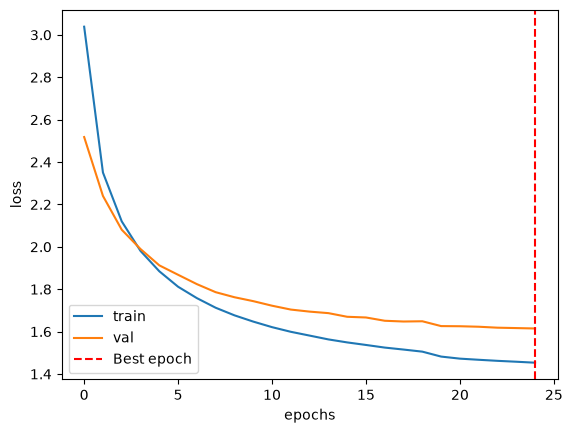

Sample 1 (seed='ROMEO:', T=0.6)
ROMEO:
I can stand a king, and thou person have should not
To she for the simble in more man with change
Are my grace on my man.

CORIOLANUS:
The power, which shall not be may here
Then Capitor of might cons

Sample 2 (seed='First Citizen:', T=0.6)
First Citizen:
And then a promises, with the father's looks,
To be no light him for a live to fair to-day
With so think and let me prince the commons,
A come more than the common a power.

PARIS:
The comfort with my

Sample 3 (seed='KING HENRY:', T=0.6)
KING HENRY:
Grow the master man in his sing both and way.

LADY CAPULET:
Well all will thou sence to his lay;
For me and well you are father, that I must be
Beming beggar to can the open with the fair.

BISHOP OF

Sample 4 (seed='JULIET:', T=0.6)
JULIET:
O forth great death, what will see me to the father?

KING RICHARD III:
And let me made a prove all the power
The talk too that you know the fellow of the death
Shall be lose and one favour with my lo

Sample 5

In [2]:
SEQ_LEN = 100        # For data split
STRIDE = 50
TRAIN_SIZE = None   # Decrease training time
VAL_SIZE = None
BATCH_SIZE = 512    # For model training
EPOCHS = 25
LENGTH = 200        # For generating output
TEMPERATURE = 0.6
SEEDS = [           # For results
    "ROMEO:\n", 
    "First Citizen:\n", 
    "KING HENRY:\n", 
    "JULIET:\n", 
    "HAMLET:\n"
] 

# data loading + preprocessing 
def load_shakespeare():
    ds = load_dataset("Trelis/tiny-shakespeare")
    col = [c for c, f in ds["train"].features.items() if f.dtype == "string"][0]
    print("Text column", col)
    return ds, col

def get_text(ds, col):
    text = "\n".join(ds["train"][col])
    val_text = "\n".join(ds["test"][col])
    print(f"Train chars: {len(text)}, Val chars: {len(val_text)}")
    return text, val_text

def get_chars(text, val_text):
    chars = sorted(set(text + val_text))
    char2idx = {c: i for i, c in enumerate(chars)}
    idx2char = np.array(chars)
    vocab_size = len(chars)
    return chars, char2idx, idx2char, vocab_size

def create_x_y(s, char2idx, seq_len=SEQ_LEN, stride=STRIDE):
    data = np.array([char2idx[c] for c in s], dtype=np.int32)
    starts = np.arange(0, len(data) - seq_len - 1, stride)
    x = np.stack([data[i: i + seq_len] for i in starts])
    y = np.stack([data[i + 1: i + seq_len + 1] for i in starts])
    return x, y

def split_ds(text, val_text, char2idx):
    x_train, y_train = create_x_y(text, char2idx)
    x_train, y_train = subset_train(x_train, y_train)
    x_val, y_val = create_x_y(val_text, char2idx)
    x_val, y_val = subset_val(x_val, y_val)
    print(f"Train seqs: {x_train.shape}, Val seqs: {x_val.shape}")
    return x_train, y_train, x_val, y_val

def subset_train(x_train, y_train, train_size=TRAIN_SIZE):
    return (x_train, y_train) if train_size is None else (x_train[:train_size], y_train[:train_size])

def subset_val(x_val, y_val, val_size=VAL_SIZE):
    return (x_val, y_val) if val_size is None else (x_val[:val_size], y_val[:val_size])

# model definition
def create_model():
    return Sequential([
        layers.Input(shape=(None,), dtype=np.int32),
        layers.Embedding(vocab_size, 64),
        layers.GRU(256, return_sequences=True),
        layers.Dropout(0.2),
        layers.GRU(128, return_sequences=True),
        layers.Dense(vocab_size)        
    ])

def compile_model(model):
    model.compile(
        optimizer=optimizers.Adam(0.01, clipnorm=1.0),
        loss=losses.SparseCategoricalCrossentropy(from_logits=True)
    )
    model.summary()

# training loop
def get_callbacks():
    return [
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1
        ),
        callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]

def train_model(model, x_train, y_train, x_val, y_val, batch_size=BATCH_SIZE, epochs=EPOCHS):
    return model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=get_callbacks()
    )
    
def plot_training(history):
    best_epoch = np.argmin(history.history["val_loss"])
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.axvline(best_epoch, color="red", linestyle="--", label="Best epoch")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.legend()
    plt.show()
    
# generate and display 5 samples
def generate(seed, length=LENGTH, temperature=TEMPERATURE):
    out = seed
    for _ in range(length):
        ctx = [char2idx.get(c, 0) for c in out[-SEQ_LEN:]]
        logits = np.asarray(model(np.array([ctx]), training=False))[0, -1]
        logits = logits / temperature
        probs = np.exp(logits - logits.max())
        probs /= probs.sum()
        out += idx2char[np.random.choice(vocab_size, p=probs)]
    return out

def print_result():
    for i, s in enumerate(SEEDS, 1):
        print(f"Sample {i} (seed={s.strip()!r}, T={TEMPERATURE})")
        print(generate(s))
        print()

if MODALITY == "text":
    # Data loading and preprocessing
    ds, col = load_shakespeare()
    text, val_text = get_text(ds, col)
    chars, char2idx, idx2char, vocab_size = get_chars(text, val_text)
    x_train, y_train, x_val, y_val = split_ds(text, val_text, char2idx)
    
    # Model definition
    model = create_model()
    compile_model(model)
    
    # Training loop
    history = train_model(model, x_train, y_train, x_val, y_val)
    plot_training(history)
    
    # Generate 5 samples
    print_result()
    
elif MODALITY == "image":
    pass  # your image experiment
else:
    raise ValueError("MODALITY must be 'text' or 'image'")


## Failure mode (Moodle `a6_failure`)

One short phrase is enough for Moodle (e.g. repetition, mode collapse, blur). Expand briefly below if useful.


*Failure mode observed:* Long term coherence: Multiple sentences dont piece well together, although most words are correct and some sentences could be plausable such as "O forth great death, what will see me to the father?" however others don't make sense and have grammatical errors and incorrect capitalisation, "To she for the simble in more man with change Are my grace on my man."


## AR vs diffusion reflection (Moodle `a6_diffusion_reflection`)

~150 words after the HF reading: compare autoregressive vs diffusion-style generation for *your* modality (quality, control, compute, failure modes).


*Your reflection (~150 words).*

My char GRU is autoregressive. It generates Shakespeare one character at a time, and can never revisit the character once it is sampled. This matches the failure mode because some words or short phrases look realistic, however it loses meaning on longer sentences and creates new words like "simble". The HF post describes diffusion as the opposite where the text is noise and refines the whole sequence in parallel, allowing for context in both directions. For small experiments autoregressive is computationally simpler and works for short models, however diffusion would likely handle the longer contexts needed for writing plays.